In [1]:
# test with supervised optimal transport loss
# comparison with unsupervised

import random
import torch
import numpy as np
import torch.nn as nn
from tqdm import tqdm
import torch.nn.functional as F
from torch.amp import GradScaler
from torch.utils.data import DataLoader
import deeplake
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score
from sklearn.decomposition import PCA
from geomloss import SamplesLoss
import time
import pandas as pd
from torch.utils.data import ConcatDataset, RandomSampler
from torch.optim.lr_scheduler import CosineAnnealingLR
import pickle
import seaborn as sns
import itertools
from dataset_OT import make_multi_WSI_dataset

seed = 42
torch.manual_seed(seed)
np.random.seed(42)
random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False 


batch_size = 512 

print('Loading starting...')
idx_range_subset1 = [i for i in range(1,52+1)]
random.shuffle(idx_range_subset1)
num_train = int(np.ceil(0.7 * len(idx_range_subset1))) 
train_range1, val_range1 = idx_range_subset1[:num_train], idx_range_subset1[num_train:]

idx_range_subset3 = [i for i in range(1,26+1)] 
random.shuffle(idx_range_subset3)
num_train = int(np.ceil(0.7 * len(idx_range_subset3))) 
train_range3, val_range3 = idx_range_subset3[:num_train], idx_range_subset3[num_train:]

akoya_loader_train_subset1 = make_multi_WSI_dataset('Subset1', train_range1, ['Akoya'], train_or_test='Train', batch_size=batch_size)
akoya_loader_val_subset1 = make_multi_WSI_dataset('Subset1', val_range1, ['Akoya'], train_or_test='Train', batch_size=batch_size)
akoya_loader_train_subset3 = make_multi_WSI_dataset('Subset3', train_range3, ['Akoya'], train_or_test='Train', batch_size=batch_size)
akoya_loader_val_subset3 = make_multi_WSI_dataset('Subset3', val_range3, ['Akoya'], train_or_test='Train', batch_size=batch_size)
leica_loader_train = make_multi_WSI_dataset('Subset3', train_range3, ['Leica'], train_or_test='Train', batch_size=batch_size)
leica_loader_val = make_multi_WSI_dataset('Subset3', val_range3, ['Leica'], train_or_test='Train', batch_size=batch_size)

akoya_loader_train = ConcatDataset([akoya_loader_train_subset1, akoya_loader_train_subset3])
akoya_loader_val = ConcatDataset([akoya_loader_val_subset1, akoya_loader_val_subset3])

len_akoya_train = len(akoya_loader_train)
len_akoya_val = len(akoya_loader_val)

len_leica_train = len(leica_loader_train)
len_leica_val = len(leica_loader_val)

len_train = len_akoya_train + len_leica_train
len_val = len_akoya_val + len_leica_val

B_A_train = round(batch_size * len_akoya_train / (len_akoya_train + len_leica_train))
B_L_train = batch_size - B_A_train 
B_A_val = round(batch_size * len_akoya_val / (len_akoya_val + len_leica_val))
B_L_val = batch_size - B_A_val

akoya_loader_train = DataLoader(akoya_loader_train, batch_size=B_A_train, shuffle=True, num_workers=6, pin_memory=True, persistent_workers=True, prefetch_factor=4)
akoya_loader_val = DataLoader(akoya_loader_val, batch_size=B_A_val, num_workers=6, pin_memory=True, persistent_workers=True, prefetch_factor=4)
leica_loader_train = DataLoader(leica_loader_train, batch_size=B_L_train, shuffle=True, num_workers=6, pin_memory=True, persistent_workers=True, prefetch_factor=4)
leica_loader_val = DataLoader(leica_loader_val, batch_size=B_L_val, num_workers=6, pin_memory=True, persistent_workers=True, prefetch_factor=4)


print("Train batches Akoya:", len(akoya_loader_train), 'batch size:', B_A_train)
print("Train batches Leica:", len(leica_loader_train), 'batch size:', B_L_train)
print("Validation batches Akoya:", len(akoya_loader_val), 'batch size:', B_A_val)
print("Validation batches Leica:", len(leica_loader_val), 'batch size:', B_L_val)

#in samples
print('len train:', len_train)



Loading starting...
Train batches Akoya: 4973 batch size: 399
Train batches Leica: 4978 batch size: 113
Validation batches Akoya: 1272 batch size: 388
Validation batches Leica: 1267 batch size: 124
len train: 2546444


In [2]:
# unsupervised
unsupervised_OT = SamplesLoss('sinkhorn', p=2, blur=0.1, scaling=0.95, verbose=False)



## Selective optimal transport

## test

In [3]:
go = False
lu_OT = []
ls_OT = []
sup_times, unsup_times = [], []
avg_sup = 0
avg_unsup = 0
device = torch.device('cuda')


if go:
    total_time = 0
    tq = tqdm(zip(akoya_loader_train, leica_loader_train),
                                                    desc=f"Timing OT losses",
                                                    total=min(len(akoya_loader_train), len(leica_loader_train)))

    for batch_akoya, batch_leica in tq:
                
        
        embedding_akoya = batch_akoya['embedding'].to(device, non_blocking=True)
        embedding_leica = batch_leica['embedding'].to(device, non_blocking=True)
        labels_akoya = batch_akoya['label'].to(device, non_blocking=True)
        labels_leica = batch_leica['label'].to(device, non_blocking=True)
        
        # supervised OT
        t0 = time.time()
        s_OT = supervised_OT_loss(embedding_akoya, embedding_leica, labels_akoya, labels_leica).cpu().detach().item()
        ls_OT.append(s_OT)
        t1 = time.time()
        sup_times.append(t1 - t0)
        
        # unsupervised OT
        t2 = time.time()
        u_OT = loss_geom(embedding_akoya, embedding_leica).cpu().detach().item()
        lu_OT.append(u_OT)
        t3 = time.time()
        unsup_times.append(t3 - t2)
        
        # update tqdm description with average times so far
        avg_sup = sum(sup_times) / len(sup_times)
        avg_unsup = sum(unsup_times) / len(unsup_times)
        tq.set_description(f"Timing OT losses | Avg sup: {avg_sup:.3f}s | Avg unsup: {avg_unsup:.3f}s")
    
    

In [4]:
import matplotlib.pyplot as plt
pr = False 
if pr:
    lu_OT_array = np.array(lu_OT) *0.1
    ls_OT_array = np.array(ls_OT) * 0.01
    
     
    fig, axes = plt.subplots(4,2, figsize=(16, 12))
    
    #no weigthing scheme
    axes[0,0].plot(lu_OT_array, label='lu') #7, median 458
    axes[0,1].plot(ls_OT_array, label='ls') #std 302, median 2300
    axes[1,0].plot(np.array(torch.tensor(dic[0])), label='s_OT Normal') #std 16, median 509
    axes[1,1].plot(np.array(torch.tensor(dic[1])), label='s_OT Stroma') #std 30 median 440
    axes[2,0].plot(np.array(torch.tensor(dic[2])), label='s_OT G3') #std 12, median 420
    axes[2,1].plot(np.array(torch.tensor(dic[3])), label='s_OT G4') #std 10, median 433
    axes[3,0].plot(np.array(torch.tensor(dic[4])), label='s_OT G5') #std 70, median 590
    plt.legend()
    #its as if the OT based loss was already performing the weighting scheme for  G5
     #7, median 440 (but only on 9% of data)
    
    
    
    #plt.title('Plot of u_OT and s_OT')
    #plt.legend()
    plt.savefig('label-OT.pdf')
    # Show the plot
    plt.show()
    
    
    
    hello = ls_OT_array
    # Basic statistics
    print("Basic Statistics for lu_OT:")
    print(f"Mean: {np.mean(hello)}")
    print(f"Median: {np.median(hello)}")
    print(f"Standard Deviation: {np.std(hello)}")
    print(f"Variance: {np.var(hello)}")
    print(f"Minimum: {np.min(hello)}")
    print(f"Maximum: {np.max(hello)}")
    
    
    
    #with the scaling factor 0.1, the std is below one for unsupervised learning, 
    #even with the scaling factor, the std of my supervised technique is high (=22)
    #lets understand why: too much weight given to G5
    #analyse the distribution of label OT losses to understand how we can weigth the sum

In [5]:

def check_label_transport(cost_fn, x, y, labels_x, labels_y, penalty=100.0, blur=0.05):
    """
    Check if the cost function encourages transport between points with same labels.
    Works with the batched (B,N,D) format expected by make_cost_fn.
    """
    if x.dim() == 2:   # (N,D) → add batch dim
        x = x.unsqueeze(0)   # (1,N,D)
    if y.dim() == 2:   # (M,D)
        y = y.unsqueeze(0)   # (1,M,D)

    B, N, D = x.shape
    _, M, _ = y.shape

    # Uniform weights with batch
    a = torch.ones(B, N, device=x.device) / N   # (B,N)
    b = torch.ones(B, M, device=y.device) / M   # (B,M)

    # Sinkhorn with dual potentials
    loss = SamplesLoss("sinkhorn", cost=cost_fn, blur=blur, potentials=True)
    F, G = loss(a, x, b, y)  # F: (B,N), G: (B,M)

    # Remove batch dimension
    F = F[0]  # (N,)
    G = G[0]  # (M,)

    # Cost matrix (B,N,M) → (N,M)
    C = cost_fn(x, y)[0]

    # Regularization parameter (same as blur)
    ε = blur  

    # Gibbs kernel
    K = torch.exp(-(C - F.unsqueeze(1) - G.unsqueeze(0)) / ε)  # (N,M)

    # Transport plan
    P = (a[0].unsqueeze(1) * K * b[0].unsqueeze(0))
    P = P / P.sum()  # normalize to sum=1

    # Same-label mask
    lx = labels_x.unsqueeze(1).expand(N, M)
    ly = labels_y.unsqueeze(0).expand(N, M)
    mask = (lx == ly).float()

    # Fraction of transport mass that goes to same-label pairs
    fraction_same_label = (P * mask).sum().item()

    #print("Total transport mass (sanity check):", P.sum().item())
    #print("Transport mass to same-label pairs:", fraction_same_label)

    return fraction_same_label




    

In [6]:

def make_cost_fn(labels_x, labels_y, M_penalty=100.0):
    """
    Create a custom cost function with label penalties for SamplesLoss.
    """

    def cost_fn(x, y):
        N = x.shape[1]
        M = y.shape[1]

        x_norm = (x ** 2).sum(dim=2, keepdim=True)        # (B,N,1)
        y_norm = (y ** 2).sum(dim=2, keepdim=True)        # (B,M,1)
        xy = torch.bmm(x, y.transpose(1, 2))              # (B,N,M)
        dist = 0.5 * (x_norm + y_norm.transpose(1, 2) - 2 * xy)
        dist = torch.clamp_(dist, min=0.0)

        #SamplesLoss compute the cost for x,y / y,x / x,x / y,y --> careful with shapes
        if N == len(labels_x) and M == len(labels_y):
            lx, ly = labels_x, labels_y
            
        elif N == len(labels_y) and M == len(labels_x):
            lx, ly = labels_y, labels_x
            
        else:
            #when same vectors x or y are used, necessarily the labels will align, no need for penalty
            return dist

        lx = lx.to(x.device, non_blocking=True)
        ly = ly.to(y.device, non_blocking=True)

        lx = lx.unsqueeze(0).unsqueeze(2)        # (1,N,1)
        ly = ly.unsqueeze(0).unsqueeze(0)        # (1,1,M)
        mismatch = (lx != ly).float().expand(1, -1, -1) # (B=1,N,M)
        #-1 means 'keep the size of this dimension dont copy'

        return dist + M_penalty * mismatch

    return cost_fn






go = True
lu_OT = []
ls_OT = []
sup_times, unsup_times = [], []
quality = []
avg_sup = 0
avg_unsup = 0
device = torch.device('cuda')

M_penalty = 1000

tq = tqdm(zip(akoya_loader_train, leica_loader_train),
                                                    desc=f"Timing OT losses",
                                                    total=min(len(akoya_loader_train), len(leica_loader_train)))

if go:
    total_time = 0
    for batch_akoya, batch_leica in tq:
                
        embedding_akoya = batch_akoya['embedding'].to(device, non_blocking=True)
        embedding_leica = batch_leica['embedding'].to(device, non_blocking=True)
        labels_akoya = batch_akoya['label'].to(device, non_blocking=True)
        labels_leica = batch_leica['label'].to(device, non_blocking=True)
        
        
        # supervised OT
        t0 = time.time()
        cost_fn_high = make_cost_fn(labels_akoya, labels_leica, M_penalty=M_penalty)
        loss_high = SamplesLoss(loss="sinkhorn", p=2, blur=0.05, 
                           backend="tensorized", cost=cost_fn_high)
        s_OT = loss_high(embedding_akoya, embedding_leica).cpu().detach().item()
        ls_OT.append(s_OT)
        frac = check_label_transport(cost_fn_high, embedding_akoya, embedding_leica, 
                             labels_akoya, labels_leica)
        quality.append(frac)
        t1 = time.time()
        sup_times.append(t1 - t0)
        
        # unsupervised OT
        '''t2 = time.time()
        u_OT = unsupervised_OT(embedding_akoya, embedding_leica).cpu().detach().item()
        lu_OT.append(u_OT)
        t3 = time.time()
        unsup_times.append(t3 - t2)'''
        
        # update tqdm description with average time and quality
        avg_sup = sum(sup_times) / len(sup_times)
        avg_quality = sum(quality) / len(quality)
        tq.set_description(f"Timing OT losses | Avg sup: {avg_sup:.3f}s | Avg quality: {avg_quality:.3f}s")
                                                                                 
print('finish')

Timing OT losses | Avg sup: 0.024s | Avg quality: 0.968s: 100%|████████████████████| 4973/4973 [02:05<00:00, 39.59it/s]

finish


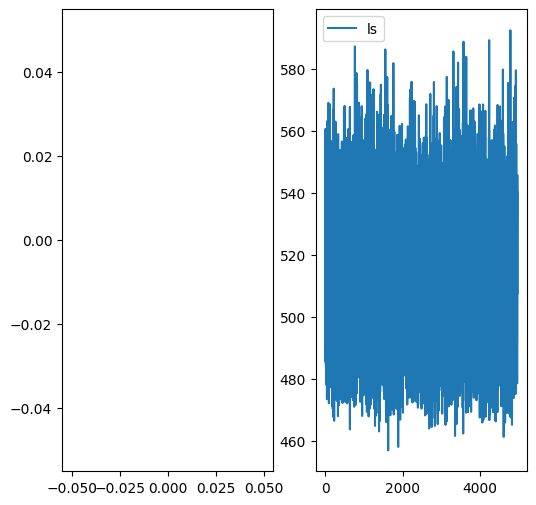

Basic Statistics for supervised:
Mean: 512.1747438855366
Median: 511.2227478027344
Standard Deviation: 25.75498672019503
Variance: 663.3193409574224
Minimum: 456.8995361328125
Maximum: 592.4336547851562
Basic Statistics for unsupervised:
Mean: nan
Median: nan
Standard Deviation: nan
Variance: nan


/home/leolr-int/micromamba/envs/py312-poetry/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/leolr-int/micromamba/envs/py312-poetry/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/leolr-int/micromamba/envs/py312-poetry/lib/python3.12/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/leolr-int/micromamba/envs/py312-poetry/lib/python3.12/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/leolr-int/micromamba/envs/py312-poetry/lib/python3.12/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type

ValueError: zero-size array to reduction operation minimum which has no identity

In [7]:
import matplotlib.pyplot as plt
lu_OT_array = np.array(lu_OT)
ls_OT_array = np.array(ls_OT)

 
fig, axes = plt.subplots(1,2, figsize=(6, 6))

#no weigthing scheme
axes[0].plot(lu_OT_array, label='lu') 
axes[1].plot(ls_OT_array, label='ls') 

plt.legend()

#plt.title('Plot of u_OT and s_OT')
#plt.legend()
plt.savefig('label-OT.pdf')
# Show the plot
plt.show()



hello = ls_OT_array
# Basic statistics
print(f"Basic Statistics for supervised:")
print(f"Mean: {np.mean(hello)}")
print(f"Median: {np.median(hello)}")
print(f"Standard Deviation: {np.std(hello)}")
print(f"Variance: {np.var(hello)}")
print(f"Minimum: {np.min(hello)}")
print(f"Maximum: {np.max(hello)}")

hello = lu_OT_array
# Basic statistics
print(f"Basic Statistics for unsupervised:")
print(f"Mean: {np.mean(hello)}")
print(f"Median: {np.median(hello)}")
print(f"Standard Deviation: {np.std(hello)}")
print(f"Variance: {np.var(hello)}")
print(f"Minimum: {np.min(hello)}")
print(f"Maximum: {np.max(hello)}")

#both are of the same magnitude

In [ ]:
import torch
from geomloss import SamplesLoss




Bad pipe message: %s [b'y\x16\xae\xc7\x15\xfe\xe5\xe2fZ\xfc\xa3\xa9]\xaej9\x91\x00\x02\xbc\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00\x05\x00\x06\x00\x07\x00\x08\x00\t\x00\n\x00\x0b\x00\x0c\x00\r\x00\x0e\x00\x0f\x00\x10\x00\x11\x00\x12\x00\x13\x00\x14\x00\x15\x00\x16\x00\x17\x00\x18\x00\x19\x00\x1a\x00\x1b\x00\x1e\x00\x1f\x00 \x00!\x00"\x00#\x00$\x00%\x00&\x00\'\x00(\x00)\x00*\x00+\x00,\x00-\x00.\x00/\x000\x001\x002\x003\x004\x005\x006\x007\x008\x009\x00:\x00;\x00<\x00=\x00>\x00?\x00@\x00A\x00B\x00C\x00D\x00E\x00F\x00g\x00h\x00i\x00j\x00k\x00l\x00m\x00\x84\x00\x85\x00\x86\x00\x87\x00\x88\x00\x89\x00\x8a\x00\x8b\x00\x8c\x00\x8d\x00\x8e\x00\x8f\x00\x90\x00\x91\x00\x92\x00\x93\x00\x94\x00\x95\x00\x96\x00\x97\x00\x98\x00\x99\x00\x9a\x00\x9b\x00\x9c\x00\x9d\x00\x9e\x00\x9f\x00\xa0']
Bad pipe message: %s [b'3\xa9\x91W\xe4\xdbk\xdcg\xe5\xec\x08\xa5\xc7a\xbac^\x00\x02\xbc\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00\x05\x00\x06\x00\x07\x00\x08\x00\t\x00\n\x00\x0b\x00\x0c\x00\r\x00\x0e\x00\x0f\